<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/Tugas%204%20AI%20Review%20Paper_Dody_NRP%206022251073.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Review Paper

Notebook ini berisi:
1. Review paper
2. Code Gambar Figure 2

Paper yang direview:
**Martina Casari, Piotr A. Kowalski, Laura Po, 2024**  
**Optimisation of the adaptive neuro-fuzzy inference system for adjusting low-cost sensors PM concentrations**



## 1. Review Paper

### 1.1 Identitas Paper
- **Judul**: *Optimisation of the adaptive neuro-fuzzy inference system for adjusting low-cost sensors PM concentrations*
- **Penulis**: Martina Casari, Piotr A. Kowalski, Laura Po
- **Jurnal**: *Ecological Informatics*
- **Tahun**: 2024
- **Fokus utama**: optimasi ANFIS untuk memperbaiki pembacaan sensor PM berbiaya rendah yang dipengaruhi oleh higroskopisitas.

### 1.2 Latar Belakang
Paper ini berangkat dari masalah praktis pada monitoring kualitas udara. Sensor PM murah sangat menarik untuk deployment skala besar, tetapi akurasinya sering turun ketika kondisi lingkungan berubah, terutama saat kelembapan relatif tinggi. Pada kondisi seperti ini, partikel dapat menyerap uap air, sehingga konsentrasi PM yang dibaca sensor menjadi bias.

Penulis menawarkan **Adaptive Neuro-Fuzzy Inference System (ANFIS)** sebagai pendekatan yang menggabungkan keunggulan:
- **fuzzy logic**, yang interpretatif dan mampu menangani ketidakpastian,
- **neural learning**, yang mampu menyesuaikan parameter dari data.

### 1.3 Tujuan Penelitian
Tujuan utama paper adalah:
1. Mengoreksi pembacaan PM dari sensor murah SPS30.
2. Membandingkan ANFIS dengan baseline machine learning lain seperti linear regression, decision tree, random forest, SVR, dan MLP.
3. Menentukan konfigurasi ANFIS terbaik dari sisi:
   - pemilihan fitur,
   - jumlah membership function,
   - jenis membership function,
   - algoritma optimasi.

### 1.4 Dataset dan Akuisisi Data
Penelitian memakai data sensor SPS30 yang dikumpulkan di Turin, Italia. Sensor murah ditempatkan bersama stasiun referensi. Paper menjelaskan bahwa fitur mentah dan tambahan yang digunakan mencakup PM1, PM2.5, PM4, PM10, relative humidity, temperature, wind speed, dan atmospheric pressure.

Penelitian juga menyoroti bahwa **RH** berperan penting terhadap deviasi pembacaan PM2.5, karena partikel higroskopis cenderung meningkat massanya saat kelembapan tinggi.

### 1.5 Tahap Pra-pemrosesan
Paper menjelaskan beberapa tahap penting:
1. Resampling data ke interval 1 jam.
2. Menghapus outlier di atas 3 standar deviasi.
3. Mengisi missing values dengan interpolasi kNN.
4. Smoothing menggunakan left-sided median cleaning.
5. Normalisasi fitur.

Tahap ini penting karena ANFIS sensitif terhadap kualitas data input. Penulis menunjukkan bahwa ukuran window smoothing memengaruhi performa, dan window **4 jam** memberi hasil terbaik pada pengujian.

### 1.6 Dataset Splitting
Penulis membandingkan dua strategi pembagian data:
- **Sequential split**
- **Random split**

Hasil paper menunjukkan bahwa **sequential split** memberi performa uji yang lebih baik dan lebih sesuai dengan sifat data deret waktu.

### 1.7 Konfigurasi ANFIS yang Dieksplorasi
Paper menguji:
- beberapa jumlah membership function per fitur,
- beberapa tipe membership function:
  - Gaussian
  - Triangular
  - Trapezoidal
- dua algoritma optimasi:
  - GridSearch
  - SubtractiveClustering

Hasil pentingnya:
- **Triangular membership function** memberi performa paling stabil.
- Mengurangi jumlah membership function membantu menurunkan overfitting.
- **GridSearch** cenderung memberi performa lebih tinggi.
- **SubtractiveClustering** lebih stabil pada beberapa konfigurasi.

### 1.8 Hasil Utama
Secara umum, paper menunjukkan:
- ANFIS mengungguli metode machine learning klasik pada banyak kombinasi fitur.
- Kinerja dinilai memakai **R²** dan **RMSE**.
- Konfigurasi fitur yang kuat adalah kombinasi yang memuat **PM2.5, RH, dan temperature**, tanpa harus menambahkan seluruh fitur lain.
- ANFIS menjaga keseimbangan antara performa dan interpretabilitas.

### 1.9 Kelebihan Paper
1. **Masalah yang dibahas sangat praktis** dan relevan.
2. **Metodologi jelas**, dari data acquisition sampai optimasi model.
3. **Komparasi model cukup lengkap**.
4. Paper tidak hanya mengejar akurasi, tetapi juga menilai stabilitas model.
5. Penjelasan fuzzy inference system membantu pembaca memahami alasan pemilihan ANFIS.

### 1.10 Kekurangan Paper
1. Penjelasan arsitektur detail ANFIS tidak terlalu panjang dibanding bagian eksperimen.
2. Generalisasi ke kota atau sensor lain masih perlu diuji lebih lanjut.
3. Paper tidak terlalu mendalam membahas interpretasi rule akhir yang terbentuk.
4. Tidak semua pembaca akan langsung bisa mereplikasi eksperimen tanpa akses penuh ke data dan kode MATLAB terkait.

### 1.11 Kesimpulan Review
Paper ini kuat secara metodologis dan aplikatif. Penulis berhasil menunjukkan bahwa ANFIS adalah metode yang layak untuk koreksi data sensor PM murah, terutama ketika sistem menghadapi ketidakpastian akibat kelembapan. Kontribusi penting paper ini bukan hanya pada performa, tetapi juga pada **keseimbangan antara akurasi, interpretabilitas, dan fleksibilitas optimasi**.



## 2. Detail 5 Layer ANFIS

Berikut penjelasan 5 layer ANFIS dalam bentuk standar Sugeno.

Misalkan input ada dua:
- $x$ = NOx
- $y$ = PM2.5

Dan ada dua rule contoh:
- Rule 1: If $x$ is $A_1$ and $y$ is $B_1$, then $f_1 = p_1x + q_1y + r_1$
- Rule 2: If $x$ is $A_2$ and $y$ is $B_2$, then $f_2 = p_2x + q_2y + r_2$

### Layer 1. Fuzzification Layer
Layer ini menghitung derajat keanggotaan tiap input terhadap membership function.

Rumus:
$$
O_{1,i} = \mu_{A_i}(x), \quad O_{1,j} = \mu_{B_j}(y)
$$

Jika memakai triangular MF:
$$
\mu(x; a,b,c)=
\begin{cases}
0, & x \le a \\
\dfrac{x-a}{b-a}, & a < x \le b \\
\dfrac{c-x}{c-b}, & b < x < c \\
0, & x \ge c
\end{cases}
$$

### Layer 2. Rule Layer
Layer ini menghitung **firing strength** tiap rule.
$$
w_i = \mu_{A_i}(x)\times \mu_{B_i}(y)
$$
atau jika operator AND memakai minimum:
$$
w_i = \min(\mu_{A_i}(x), \mu_{B_i}(y))
$$

### Layer 3. Normalization Layer
Layer ini menormalisasi firing strength.
$$
\bar{w}_i = \frac{w_i}{\sum_j w_j}
$$

### Layer 4. Consequent Layer
Untuk model Sugeno orde-1:
$$
O_{4,i} = \bar{w}_i f_i = \bar{w}_i (p_ix + q_iy + r_i)
$$

Untuk singleton output:
$$
O_{4,i} = \bar{w}_i c_i
$$

### Layer 5. Output Layer
Layer ini menjumlahkan seluruh kontribusi rule.
$$
O_{5,1} = \sum_i \bar{w}_i f_i
$$

### Ringkasan
1. Layer 1: membership calculation  
2. Layer 2: firing strength  
3. Layer 3: normalization  
4. Layer 4: weighted consequent  
5. Layer 5: overall crisp output



## 3. Replikasi Fig. 2

Fig. 2 pada paper menunjukkan urutan proses fuzzy inference:
- (a) Input membership functions
- (b) Fuzzification
- (c) Rules
- (d) Inference
- (e) Aggregation and defuzzification

Contoh input yang dipakai:
- **NOx = 7**
- **PM2.5 = 75**

Output:
- **AQI** dengan kelas:
  - good
  - moderate
  - poor

Operator:
- AND = minimum
- OR = maksimum
- Defuzzification = centroid


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 11



## 4. Rumusan Matematis

### Triangular Membership Function
$$
\mu(x; a,b,c)=
\begin{cases}
0, & x \le a \\
\dfrac{x-a}{b-a}, & a < x \le b \\
\dfrac{c-x}{c-b}, & b < x < c \\
0, & x \ge c
\end{cases}
$$

### Operator Fuzzy
AND:
$$
x \land y = \min(\mu(x), \mu(y))
$$

OR:
$$
x \lor y = \max(\mu(x), \mu(y))
$$

NOT:
$$
\neg x = 1 - \mu(x)
$$

### Centroid Defuzzification
$$
AQI^* = \frac{\int z \cdot \mu_{agg}(z)\,dz}{\int \mu_{agg}(z)\,dz}
$$


In [2]:

def trimf(x, abc):
    a, b, c = abc
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)

    left = (a < x) & (x <= b)
    if b != a:
        y[left] = (x[left] - a) / (b - a)
    else:
        y[x == a] = 1.0

    right = (b < x) & (x < c)
    if c != b:
        y[right] = (c - x[right]) / (c - b)
    else:
        y[x == b] = 1.0

    y[x == b] = 1.0
    return np.maximum(y, 0.0)

def interp_membership(x, mf, val):
    return float(np.interp(val, x, mf))


In [3]:

# Universe of discourse
x_nox = np.linspace(0, 10, 1001)
x_pm25 = np.linspace(0, 100, 1001)
x_aqi = np.linspace(0, 300, 3001)

# Input MFs
nox_low = trimf(x_nox, [0, 0, 5])
nox_med = trimf(x_nox, [0, 5, 10])
nox_high = trimf(x_nox, [5, 10, 10])

pm_low = trimf(x_pm25, [0, 0, 50])
pm_med = trimf(x_pm25, [0, 50, 100])
pm_high = trimf(x_pm25, [50, 100, 100])

# Output MFs
aqi_good = trimf(x_aqi, [0, 0, 100])
aqi_moderate = trimf(x_aqi, [0, 100, 200])
aqi_poor = trimf(x_aqi, [100, 200, 300])

# Sample values
nox_val = 7
pm_val = 75

# Fuzzification
mu_nox_low = interp_membership(x_nox, nox_low, nox_val)
mu_nox_med = interp_membership(x_nox, nox_med, nox_val)
mu_nox_high = interp_membership(x_nox, nox_high, nox_val)

mu_pm_low = interp_membership(x_pm25, pm_low, pm_val)
mu_pm_med = interp_membership(x_pm25, pm_med, pm_val)
mu_pm_high = interp_membership(x_pm25, pm_high, pm_val)

print("NOx memberships:", mu_nox_low, mu_nox_med, mu_nox_high)
print("PM2.5 memberships:", mu_pm_low, mu_pm_med, mu_pm_high)


NOx memberships: 0.0 0.6 0.4
PM2.5 memberships: 0.0 0.5 0.5


In [4]:

# Rules
rule1 = min(mu_nox_low, mu_pm_low)
rule2 = max(mu_nox_med, mu_pm_med)
rule3 = max(mu_nox_high, mu_pm_high)

print("Rule 1 inference:", rule1)
print("Rule 2 inference:", rule2)
print("Rule 3 inference:", rule3)


Rule 1 inference: 0.0
Rule 2 inference: 0.6
Rule 3 inference: 0.5


In [5]:

# Implication
aqi_good_cut = np.fmin(rule1, aqi_good)
aqi_mod_cut = np.fmin(rule2, aqi_moderate)
aqi_poor_cut = np.fmin(rule3, aqi_poor)

# Aggregation
aqi_agg = np.fmax(aqi_good_cut, np.fmax(aqi_mod_cut, aqi_poor_cut))

# Defuzzification
aqi_value = np.trapz(x_aqi * aqi_agg, x_aqi) / np.trapz(aqi_agg, x_aqi)
print("AQI:", round(aqi_value, 2))


AQI: 146.64


/tmp/ipykernel_9936/445446430.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aqi_value = np.trapz(x_aqi * aqi_agg, x_aqi) / np.trapz(aqi_agg, x_aqi)


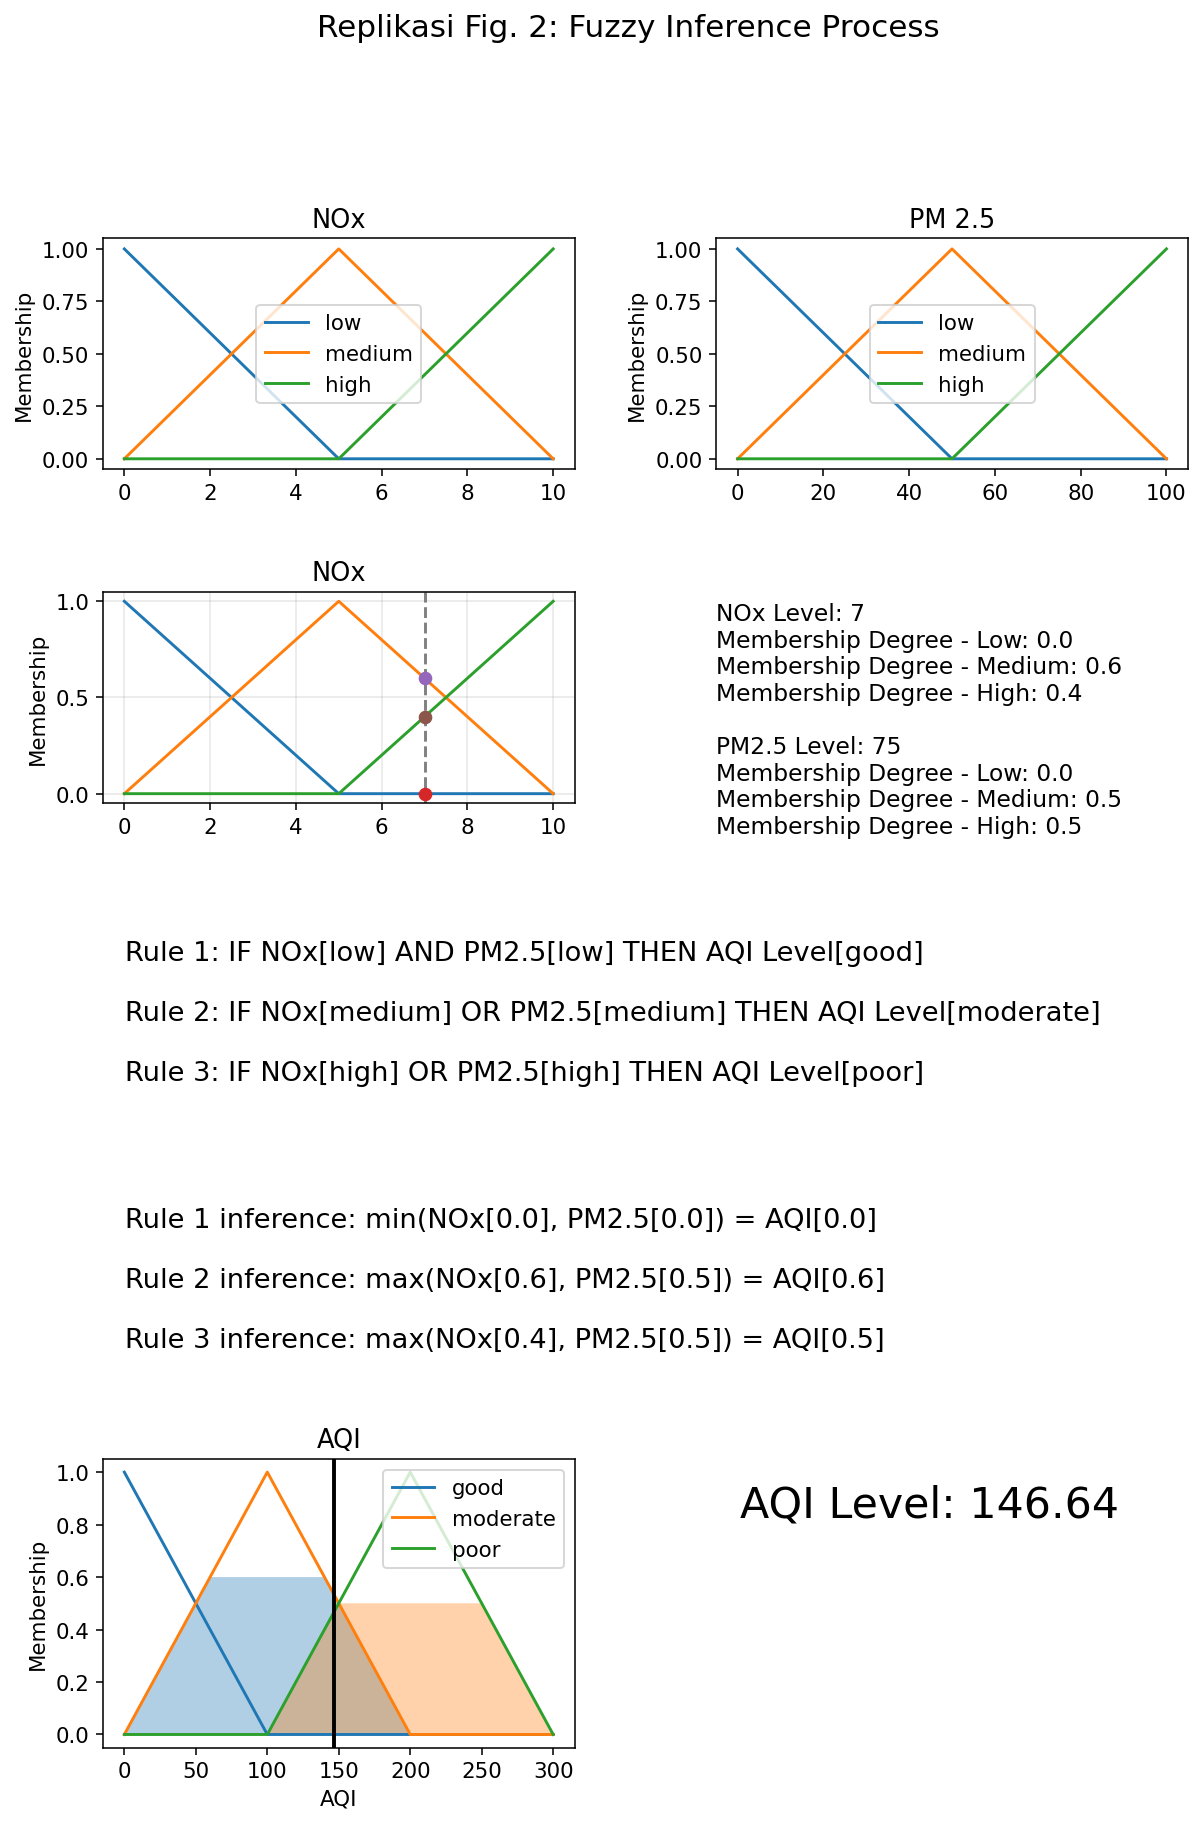

In [6]:

fig = plt.figure(figsize=(10, 14))
gs = GridSpec(5, 2, figure=fig, height_ratios=[1.2, 1.1, 0.75, 0.75, 1.5], hspace=0.6, wspace=0.3)

# (a) Input variables membership functions
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x_nox, nox_low, label='low')
ax1.plot(x_nox, nox_med, label='medium')
ax1.plot(x_nox, nox_high, label='high')
ax1.set_title("NOx")
ax1.set_ylabel("Membership")
ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(x_pm25, pm_low, label='low')
ax2.plot(x_pm25, pm_med, label='medium')
ax2.plot(x_pm25, pm_high, label='high')
ax2.set_title("PM 2.5")
ax2.set_ylabel("Membership")
ax2.legend()

# (b) Fuzzification
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(x_nox, nox_low, label='low')
ax3.plot(x_nox, nox_med, label='medium')
ax3.plot(x_nox, nox_high, label='high')
ax3.axvline(nox_val, ls='--', color='gray')
ax3.plot(nox_val, mu_nox_low, 'o')
ax3.plot(nox_val, mu_nox_med, 'o')
ax3.plot(nox_val, mu_nox_high, 'o')
ax3.set_title("NOx")
ax3.set_ylabel("Membership")
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
txt = (
    f"NOx Level: {nox_val}\n"
    f"Membership Degree - Low: {mu_nox_low:.1f}\n"
    f"Membership Degree - Medium: {mu_nox_med:.1f}\n"
    f"Membership Degree - High: {mu_nox_high:.1f}\n\n"
    f"PM2.5 Level: {pm_val}\n"
    f"Membership Degree - Low: {mu_pm_low:.1f}\n"
    f"Membership Degree - Medium: {mu_pm_med:.1f}\n"
    f"Membership Degree - High: {mu_pm_high:.1f}"
)
ax4.text(0, 0.95, txt, va='top', fontsize=12)

# (c) Rules
ax5 = fig.add_subplot(gs[2, :])
ax5.axis("off")
rules_text = (
    "Rule 1: IF NOx[low] AND PM2.5[low] THEN AQI Level[good]\n\n"
    "Rule 2: IF NOx[medium] OR PM2.5[medium] THEN AQI Level[moderate]\n\n"
    "Rule 3: IF NOx[high] OR PM2.5[high] THEN AQI Level[poor]"
)
ax5.text(0.02, 0.9, rules_text, va='top', fontsize=14)

# (d) Inference
ax6 = fig.add_subplot(gs[3, :])
ax6.axis("off")
infer_text = (
    f"Rule 1 inference: min(NOx[{mu_nox_low:.1f}], PM2.5[{mu_pm_low:.1f}]) = AQI[{rule1:.1f}]\n\n"
    f"Rule 2 inference: max(NOx[{mu_nox_med:.1f}], PM2.5[{mu_pm_med:.1f}]) = AQI[{rule2:.1f}]\n\n"
    f"Rule 3 inference: max(NOx[{mu_nox_high:.1f}], PM2.5[{mu_pm_high:.1f}]) = AQI[{rule3:.1f}]"
)
ax6.text(0.02, 0.9, infer_text, va='top', fontsize=14)

# (e) Aggregation and defuzzification
ax7 = fig.add_subplot(gs[4, 0])
ax7.plot(x_aqi, aqi_good, label='good')
ax7.plot(x_aqi, aqi_moderate, label='moderate')
ax7.plot(x_aqi, aqi_poor, label='poor')
ax7.fill_between(x_aqi, 0, aqi_mod_cut, alpha=0.35)
ax7.fill_between(x_aqi, 0, aqi_poor_cut, alpha=0.35)
ax7.fill_between(x_aqi, 0, aqi_good_cut, alpha=0.20)
ax7.axvline(aqi_value, color='k', lw=2)
ax7.set_title("AQI")
ax7.set_xlabel("AQI")
ax7.set_ylabel("Membership")
ax7.legend()

ax8 = fig.add_subplot(gs[4, 1])
ax8.axis("off")
ax8.text(0.05, 0.8, f"AQI Level: {aqi_value:.2f}", fontsize=22)

fig.suptitle("Replikasi Fig. 2: Fuzzy Inference Process", y=0.995, fontsize=16)
plt.show()



## 6. Interpretasi Hasil

Dari contoh ini:
- NOx = 7 menghasilkan:
  - low = 0.0
  - medium = 0.6
  - high = 0.4
- PM2.5 = 75 menghasilkan:
  - low = 0.0
  - medium = 0.5
  - high = 0.5

Sehingga:
- Rule 1 aktif 0.0
- Rule 2 aktif 0.6
- Rule 3 aktif 0.5

Setelah agregasi dan defuzzifikasi centroid, diperoleh nilai AQI crisp di sekitar 146.64. Nilai ini berada pada area transisi antara **moderate** dan **poor**, dengan pengaruh moderate yang masih dominan.
